In [25]:
!pip install scikit-image
!pip install opencv-python
!pip install matplotlib

  Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.4.3 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.4.3 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.3 which is incompatible.
scipy 1.13.1 requires numpy<2.3,>=1.22.4, but you have numpy 2.4.3 which is incompatible.
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cache

In [26]:
import cv2
import matplotlib.pyplot as plt

def read_image(imagem):
    image = cv2.imread(imagem)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image_rgb

def show_image(imagem):
    plt.imshow(imagem)
    plt.axis('off')
    plt.show


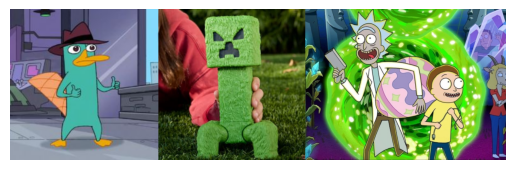

In [27]:
avatares = read_image('avatares.png')
show_image(avatares)

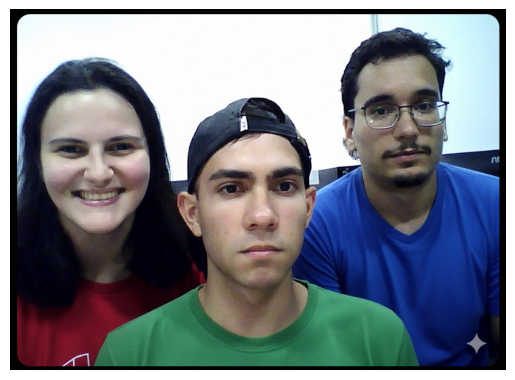

In [28]:
foto_grupo = read_image('foto-grupo.jpeg')
show_image(foto_grupo)

In [60]:
import numpy as np

DELAY_CAPTION = 1500
DELAY_BLUR = 100
MAX_KERNEL_LENGTH = 31
 
src = None
dst = None
window_name = 'Smoothing Demo'

def display_dst(delay):
    cv2.imshow(window_name, dst)
    c = cv2.waitKey(delay)
    if c >= 0 : return -1
    return 0

def display_caption(caption):
    global dst
    dst = np.zeros(src.shape, src.dtype)
    rows, cols, _ch = src.shape
    cv2.putText(dst, caption,
                (int(cols / 4), int(rows / 2)),
                cv2.FONT_HERSHEY_COMPLEX, 1, (255, 255, 255))
    
    return display_dst(DELAY_CAPTION)

def mediana(imagem):
    global src
    src = imagem
    
    if display_caption('Median Blur') != 0:
        return 0

    kernels = [3, 5, 11, 29]
    resultados = {}

    for k in kernels:
        dst = cv2.medianBlur(src,k)
        nome_arquivo = f'borramento_mediano{k}x{k}.jpg'
        imagem_correta = cv2.cvtColor(dst, cv2.COLOR_BGR2RGB)
        cv2.imwrite(nome_arquivo, imagem_correta)
        resultados[k] = dst
        print("imagem salva com sucesso")

        if display_dst(DELAY_BLUR) != 0:
            return 0

    return dst


def gaussian(imagem):
    global src
    src = imagem

    # Aplicando o borramento gausiiano
    if display_caption('Gaussian Blur') != 0:
        return 0

    kernels = [3, 5, 11, 29]
    resultados = {}

    for k in kernels:
        dst = cv2.GaussianBlur(src, (k,k), 0)  # tupla (k,k) e sigmaX=0
        nome_arquivo = f'borramento_gaussiano{k}x{k}.jpg'
        cv2.imwrite(nome_arquivo, dst)
        resultados[k] = dst
        print("imagem salva com sucesso")

        if display_dst(DELAY_BLUR) != 0:
            return 0

    return dst


def bilateral(imagem):
    global src
    src = imagem

    # aplicando filtro bilateral
    if display_caption('Bilateral Blur') != 0:
        return 0
 
    kernels = [3, 5, 11, 29]
    resultados = {}

    for k in kernels:
        dst = cv2.bilateralFilter(src, k, k*2, k/2)  
        nome_arquivo = f'borramento_bilateral{k}x{k}.jpg'
        cv2.imwrite(nome_arquivo, dst)
        resultados[k] = dst
        print("imagem salva com sucesso")

        if display_dst(DELAY_BLUR) != 0:
            return 0

    return dst

def media(imagem):
    global src
    src = imagem

    # aplicando filtro de media
    if display_caption('Homogeneous Blur') != 0:
        return 0
 
    
    kernels = [3, 5, 11, 29]
    resultados = {}

    for k in kernels:
        dst = cv2.blur(src, (k,k))
        nome_arquivo = f'borramento_media{k}x{k}.jpg'
        cv2.imwrite(nome_arquivo, dst)
        resultados[k] = dst
        print("imagem salva com sucesso")

        if display_dst(DELAY_BLUR) != 0:
            return 0

    return dst


imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


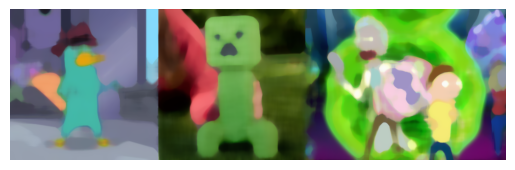

In [61]:
imagem_suavizada = mediana(avatares)
show_image(imagem_suavizada)

imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


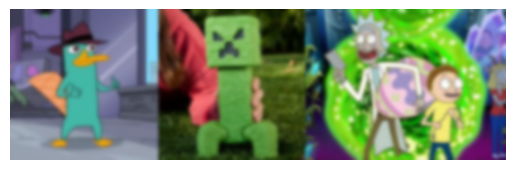

In [31]:
gaussiano = gaussian(avatares)
show_image(gaussiano)

imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


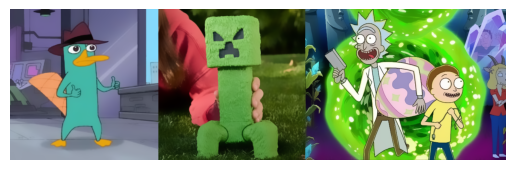

In [32]:
bilateral = bilateral(avatares)
show_image(bilateral)

imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


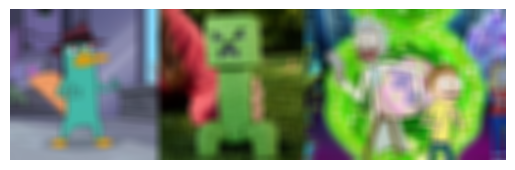

In [33]:
media = media(avatares)
show_image(media)

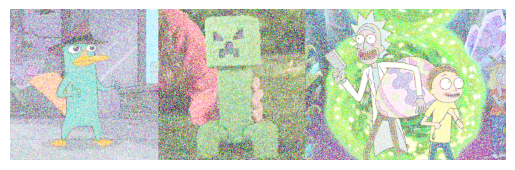

In [36]:
def add_gaussian_noise(imagem, mean=0, std=25):
    noise = np.random.normal(mean,std,imagem.shape).astype(np.uint8)
    noisy_image = cv2.add(imagem, noise)
    return noisy_image

img_ruido = add_gaussian_noise(avatares)
show_image(img_ruido)

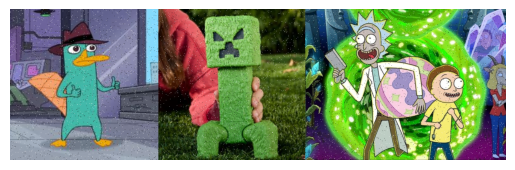

In [37]:
def add_salt_and_pepper_noise(image, noise_ratio=0.02):
    noisy_image = image.copy()
    h, w, c = noisy_image.shape
    noisy_pixels = int(h * w * noise_ratio)
 
    for _ in range(noisy_pixels):
        row, col = np.random.randint(0, h), np.random.randint(0, w)
        if np.random.rand() < 0.5:
            noisy_image[row, col] = [0, 0, 0] 
        else:
            noisy_image[row, col] = [255, 255, 255]
 
    return noisy_image

img_sal_pimenta = add_salt_and_pepper_noise(avatares)
show_image(img_sal_pimenta)

imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


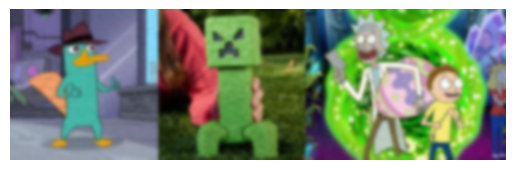

In [38]:
gaussiano_recuperacao = gaussian(img_sal_pimenta)
show_image(gaussiano_recuperacao)

imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


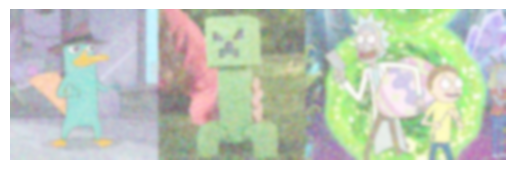

In [40]:
gaussiano = gaussian(img_ruido)
show_image(gaussiano)

In [51]:
import numpy as np

def sam (I1,I2):
  '''
  :param I1: represents original image matrix
  :param I2: represents degraded image matrix
  :returns:  float -- sam value.
  '''
  # I1,I2 = _initial_check(I1,I2)
  
  I1 = I1.reshape((I1.shape[0]*I1.shape[1],I1.shape[2]))
  I2 = I2.reshape((I2.shape[0]*I2.shape[1],I2.shape[2]))
  
  N = I1.shape[1]
  sam_angles = np.zeros(N)
  for i in range(I1.shape[1]):
    val = np.clip(np.dot(I1[:,i],I2[:,i]) / (np.linalg.norm(I1[:,i])*np.linalg.norm(I2[:,i])),-1,1)  
    sam_angles[i] = np.arccos(val)
  
  return np.mean(sam_angles)




1.5707963201677055


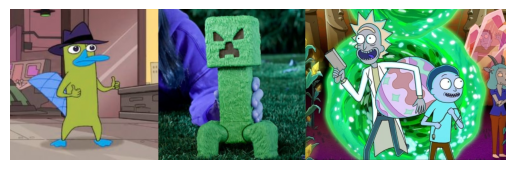

In [54]:
comparacao = sam(avatares, img_ruido)
print(comparacao) 

img = './borramento_bilateral3x3.jpg'
imagem = read_image(img)
show_image(imagem)